In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report
from sklearn.metrics import roc_curve , roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
from sklearn.model_selection import RepeatedKFold,cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## Column Details:

age:Age of the patients (min: 29, max: 77, mean: 54.4).

sex:Gender (0 = female, 1 = male).

cp:Chest pain type (0-3).

trestbps:Resting blood pressure (mean: 131.6 mm Hg).

chol:Serum cholesterol in mg/dl (range: 126-564, mean: 246).

fbs:  Fasting blood sugar > 120 mg/dl (0 = False, 1 = True). 

restecg:  Resting ECG results (0-2).

thalach:  Maximum heart rate achieved (mean: 149.1 bpm).

exang:  Exercise-induced angina (0 = No, 1 = Yes).

oldpeak:  ST depression induced by exercise relative to rest.

slope:  Slope of the peak exercise ST segment (0-2).

ca:  Number of major vessels (0-4) colored by fluoroscopy.

thal:  Thalassemia status (0-3).

target: Presence of heart disease (0 = No, 1 = Yes).

In [4]:
df.shape

(1025, 14)

we have 1025 records and 14 features

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## no null values

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## no missing values

In [9]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target_col = 'target'

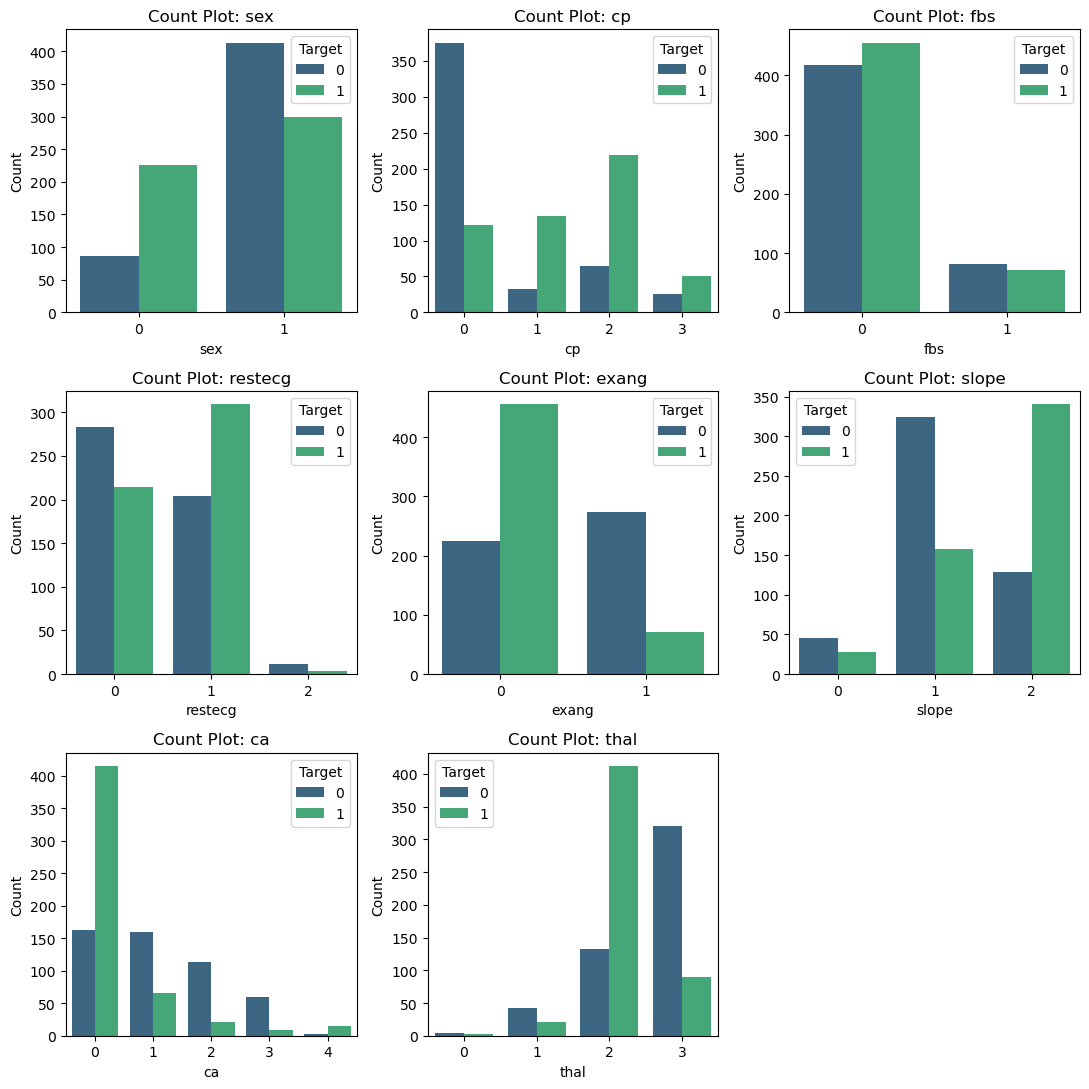

In [10]:
plt.figure(figsize=(11, 11))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, hue=target_col, palette='viridis')
    plt.title(f'Count Plot: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Target', loc='best')
plt.tight_layout()
plt.show()

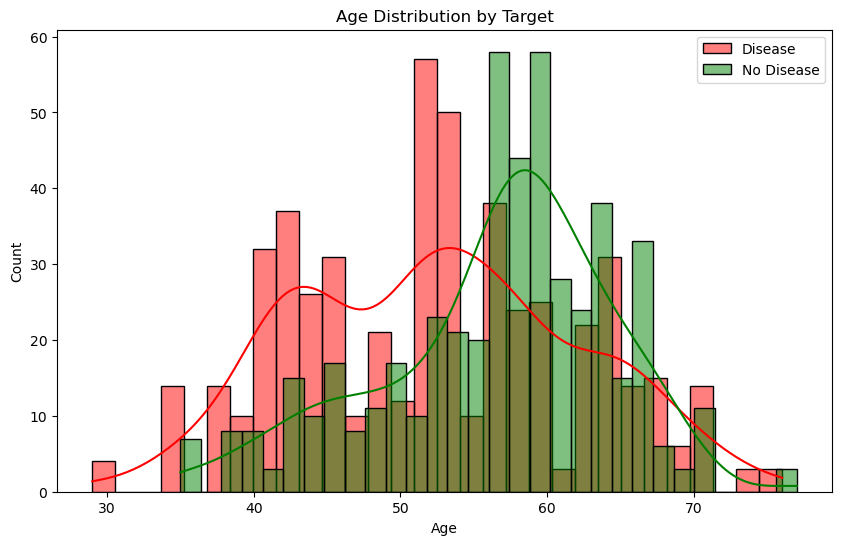

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['target'] == 1]['age'], bins=30, color='red', label='Disease', kde=True)
sns.histplot(df[df['target'] == 0]['age'], bins=30, color='green', label='No Disease', kde=True)
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

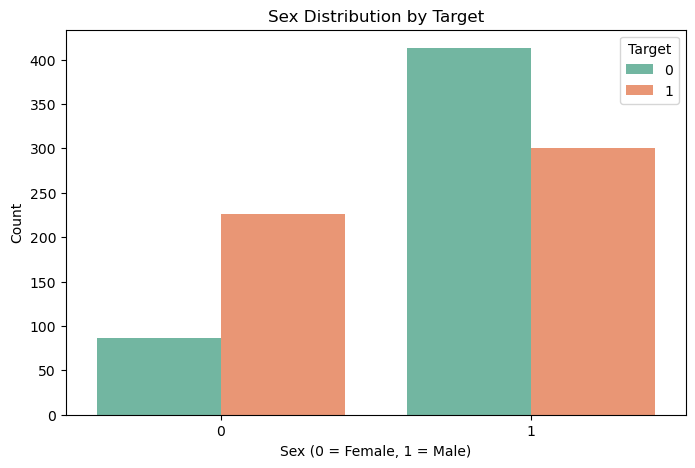

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='target', data=df, palette='Set2')
plt.title('Sex Distribution by Target')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.legend(title='Target')
plt.show()

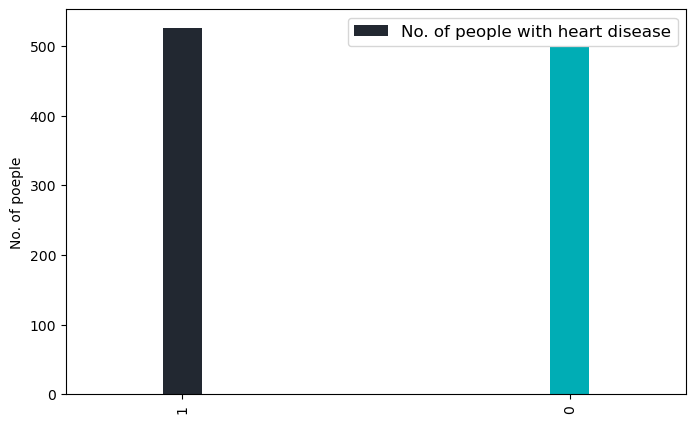

In [13]:
df.target.value_counts().plot(kind="bar",width=0.1,color=["#222831","#00ADB5"],legend=1,figsize=(8,5))
plt.ylabel('No. of poeple')
plt.legend(["No. of people with heart disease"],fontsize=12);
plt.show()

### we can see from the plot that There are approximately the same number of people with and without heart disease.

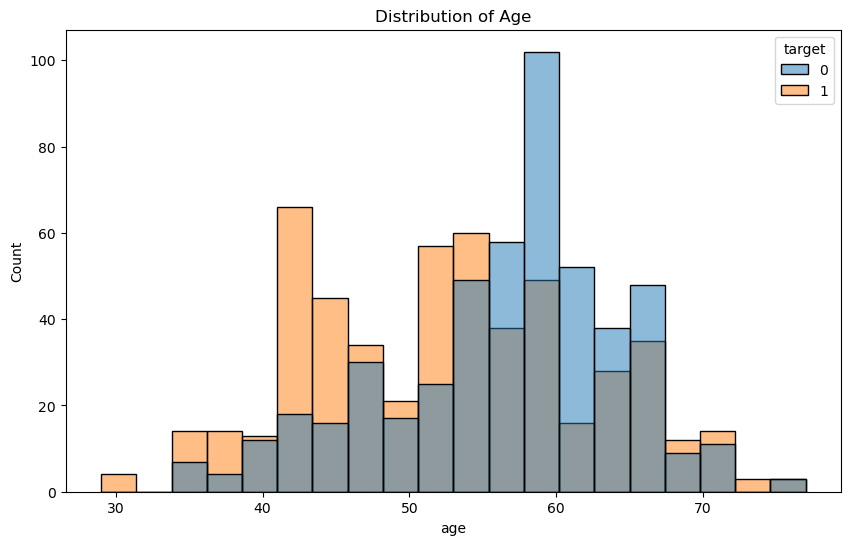

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', bins=20)
plt.title('Distribution of Age')
plt.show()

### Most patients are between 50-65 years old
### Disease (target=1) is more prevalent in middle-aged groups (50-60)
### Very few cases below 35 or above 75 years

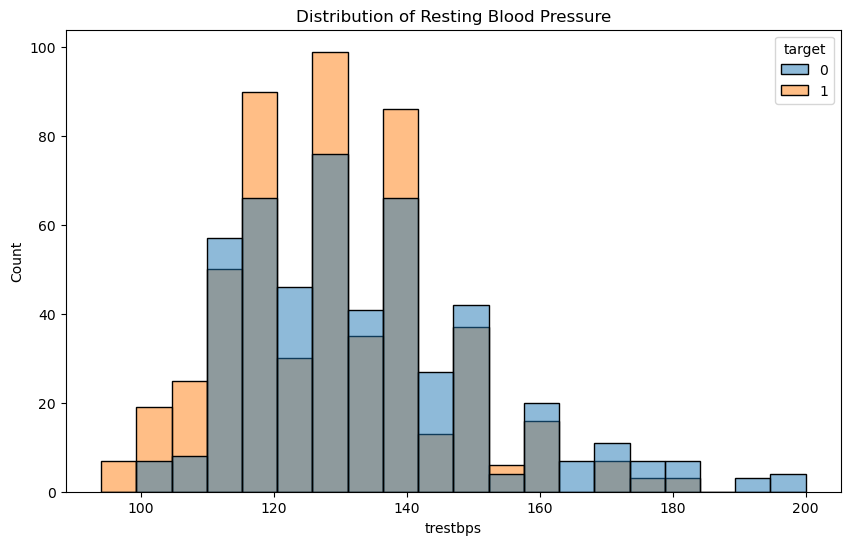

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='trestbps', hue='target', bins=20)
plt.title('Distribution of Resting Blood Pressure')
plt.show()

### Majority have resting BP between 120-140 mmHg
### Disease cases show slightly higher BP values overall
### Notable spike around 130-140 mmHg for both groups

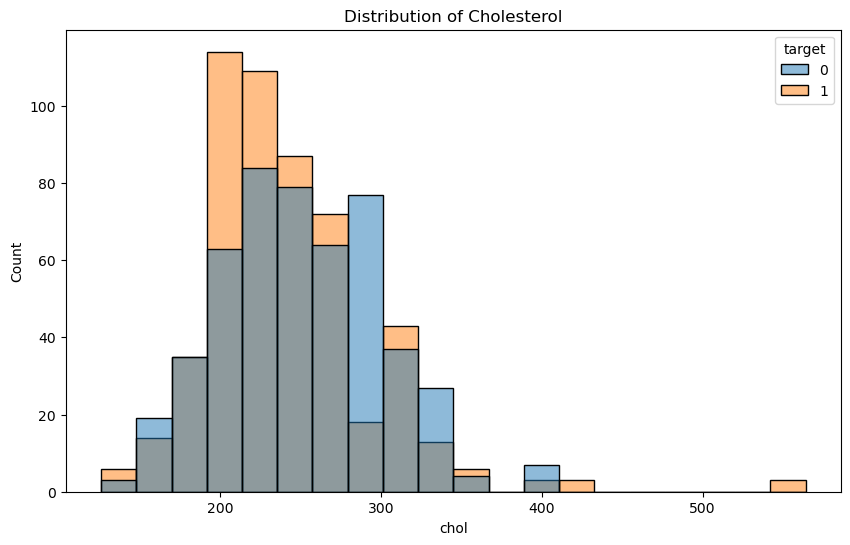

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='chol', hue='target', bins=20)
plt.title('Distribution of Cholesterol')
plt.show()


### Wide distribution from 150-350 mg/dl
### Peak around 200-250 mg/dl
### Disease cases slightly more frequent in higher cholesterol ranges
### Distribution is relatively symmetric for both groups

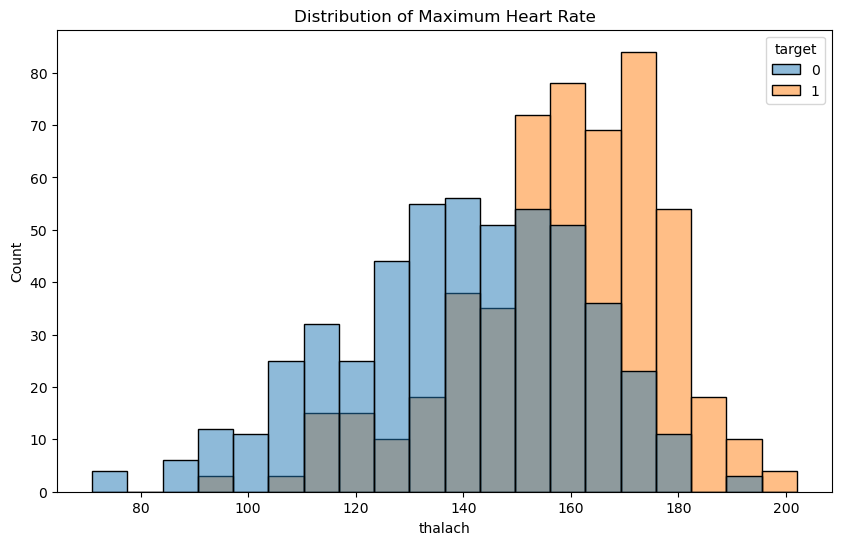

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='thalach', hue='target', bins=20)
plt.title('Distribution of Maximum Heart Rate')
plt.show()

### Healthy cases (target=0) tend toward higher max heart rates (150-180)
### Disease cases show lower max heart rates overall
### Clear separation between groups, suggesting this is an important predictor

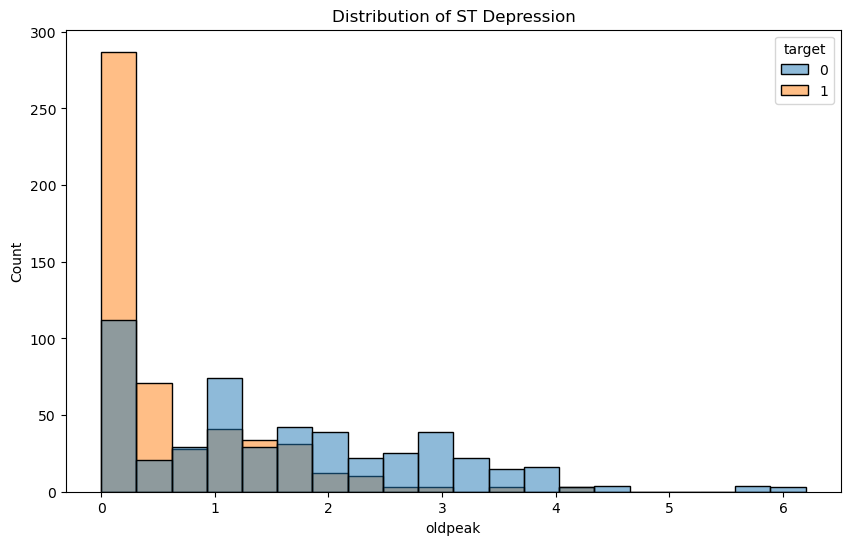

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='oldpeak', hue='target', bins=20)
plt.title('Distribution of ST Depression')
plt.show()

### Healthy cases concentrated near 0
### Disease cases show higher ST depression values
### Highly skewed distribution
### Strong predictor as there's clear separation between groups

## These visualizations suggest that max heart rate and ST depression are particularly strong indicators of heart disease.

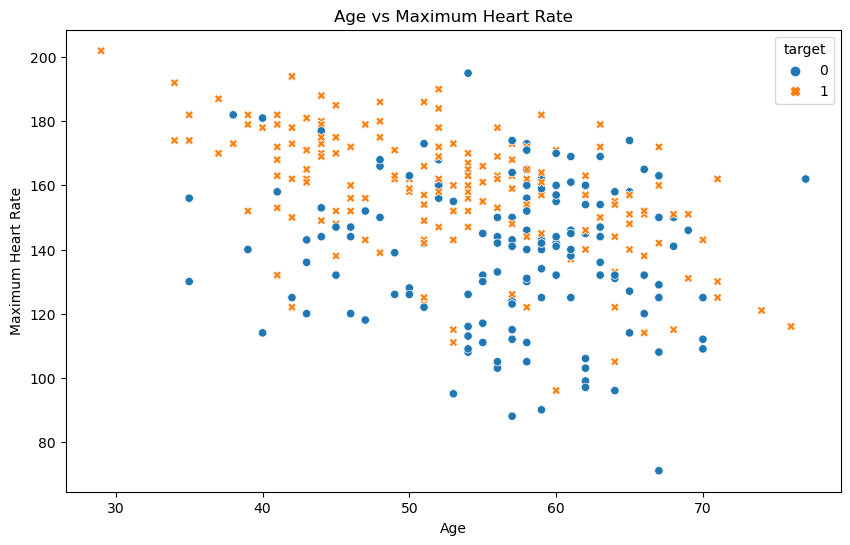

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', style='target')
plt.title('Age vs Maximum Heart Rate')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.show()

### Shows inverse relationship between age and max heart rate, with disease cases clustering at lower heart rates

<Figure size 1000x600 with 0 Axes>

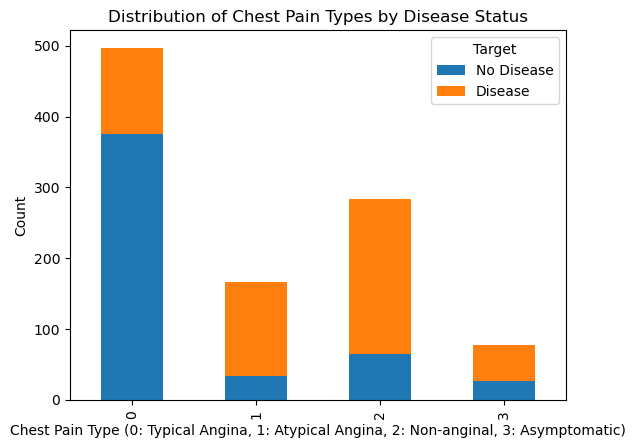

In [20]:
plt.figure(figsize=(10, 6))
cp_counts = df.groupby(['cp', 'target']).size().unstack()
cp_counts.plot(kind='bar', stacked=True)
plt.title('Distribution of Chest Pain Types by Disease Status')
plt.xlabel('Chest Pain Type (0: Typical Angina, 1: Atypical Angina, 2: Non-anginal, 3: Asymptomatic)')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.show()


### Asymptomatic chest pain (type 3) has highest disease correlation

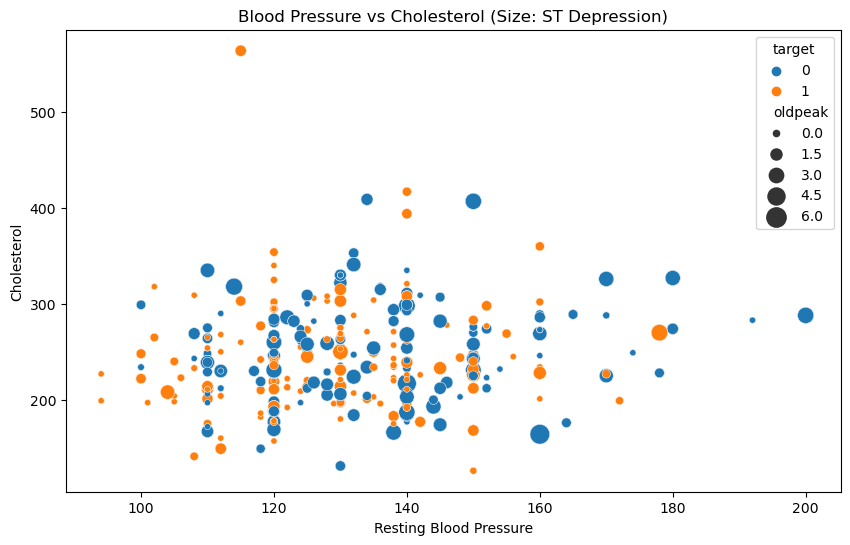

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='trestbps', y='chol', hue='target', 
                size='oldpeak', sizes=(20, 200))
plt.title('Blood Pressure vs Cholesterol (Size: ST Depression)')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Cholesterol')
plt.show()


 ### Disease cases tend to cluster in higher BP ranges, with larger ST depression (bigger dots)

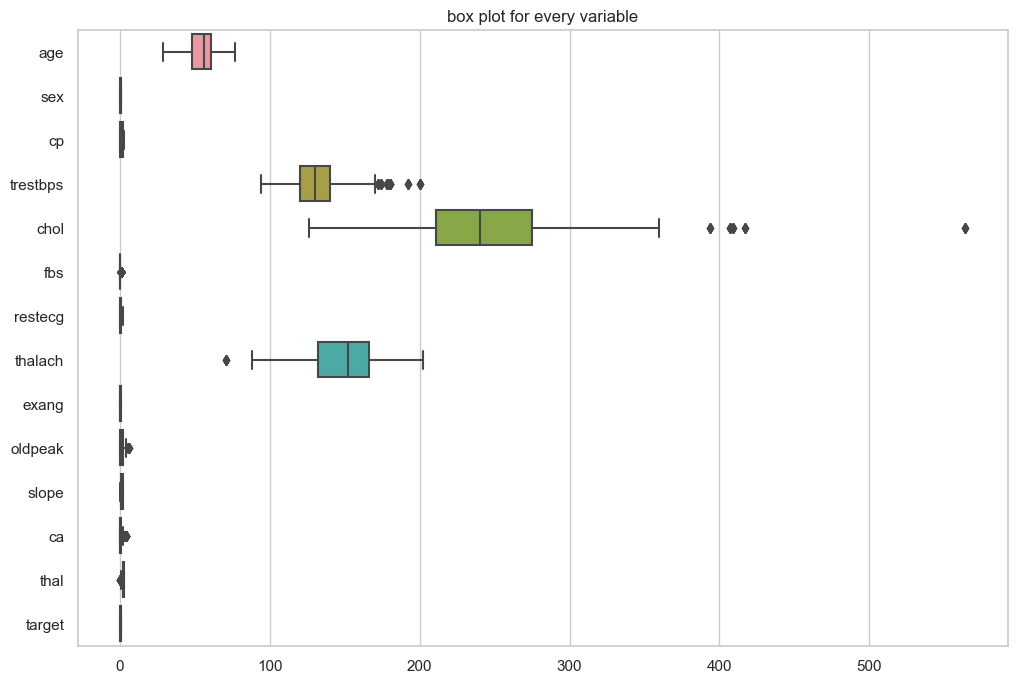

(1025, 14)


In [22]:
plt.figure(figsize = (12, 8 ))
sns.set(style ="whitegrid")
sns.boxplot(data = df, orient = "h")
plt.title("box plot for every variable")
plt.show()
print(df.shape)

In [23]:
outliersColumns = ['trestbps', 'chol','thalach']
for column in outliersColumns:
    if df[column].dtype in ["int64", "float64"]:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lowerBound = q1 - 1.5 * iqr
        upperBound = q3 + 1.5 * iqr
        df = df [(df[column] >= lowerBound) & (df[column] <= upperBound)]

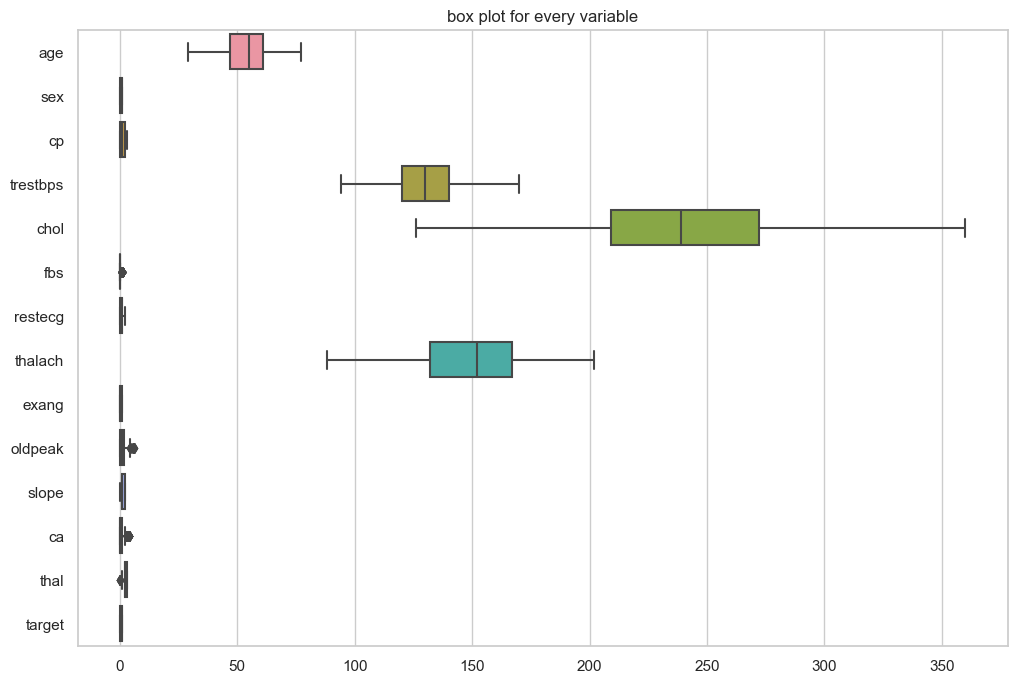

(975, 14)


In [24]:
plt.figure(figsize = (12, 8 ))
sns.set(style ="whitegrid")
sns.boxplot(data = df, orient = "h")
plt.title("box plot for every variable")
plt.show()
print(df.shape)

<AxesSubplot:>

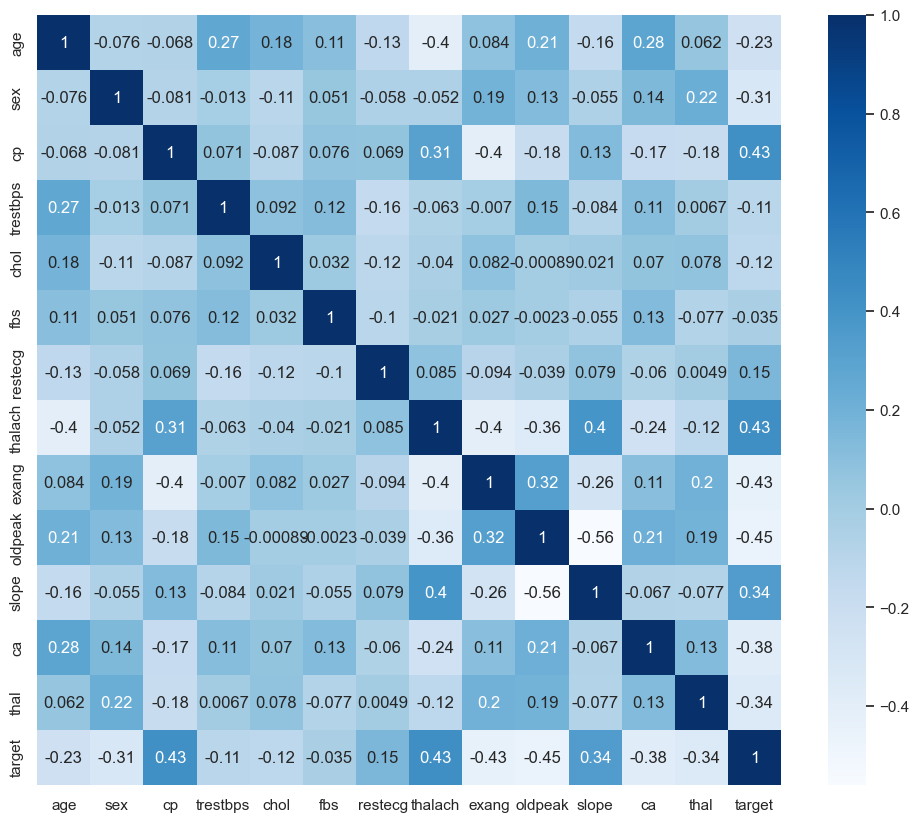

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot = True,cmap = 'Blues')

In [26]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

### splitting the data into training and testing

In [27]:
X, y = df.drop('target',axis = 1),df['target']

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state = 9)

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## the Random Forest Model

In [29]:
rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)



y_pred = rfc.predict(X_test)
print("Classification Report (rfc):")
print(classification_report(y_test, y_pred))

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')


Classification Report (rfc):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        85
           1       1.00      0.97      0.99       110

    accuracy                           0.98       195
   macro avg       0.98      0.99      0.98       195
weighted avg       0.99      0.98      0.98       195

Accuracy: 0.98


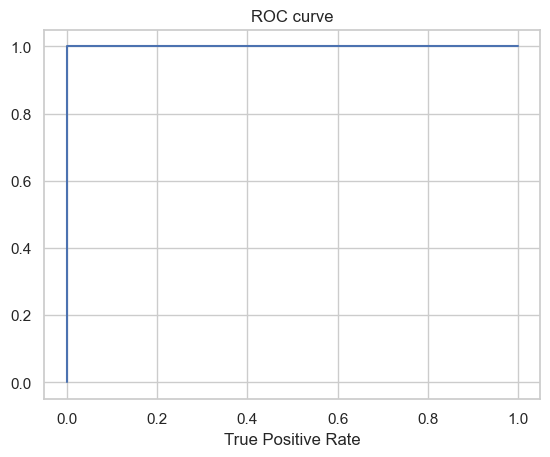

ROC score: 1.00


In [30]:
y_prob = rfc.predict_proba(X_test)[:,1]

falsePosRate, truePosRate, threshold = roc_curve(y_test, y_prob)

plt.plot(falsePosRate, truePosRate)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("ROC curve")
plt.show()

score = roc_auc_score(y_test, y_prob)
print(f'ROC score: {score:.2f}')

## Perfect Discrimination: The model achieves 100% accuracy in separating the positive and negative classes. This means that:
## Every positive instance is correctly identified as positive (no false negatives).
## Every negative instance is correctly identified as negative (no false positives).

In [31]:
param_grid = {
    'n_estimators': [100,200,500],
    'max_depth': [None,10,20,30],
}

forest = RandomForestClassifier()

gridSearch = GridSearchCV(forest, param_grid, cv = 3)

gridSearch.fit(X_train,y_train)

bestForest = gridSearch.best_estimator_
print(bestForest)

RandomForestClassifier(max_depth=10, n_estimators=200)


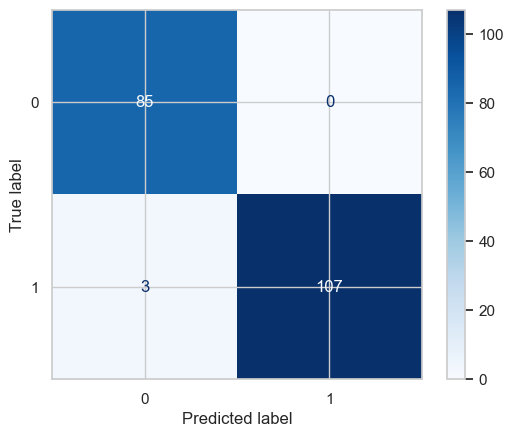

In [32]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
disp.plot(cmap="Blues")
plt.show()

In [33]:
rkf = RepeatedKFold(n_splits= 5, n_repeats=10, random_state=42)

rfc_cross = cross_val_score(estimator = rfc, X = X_train, y = y_train, cv = rkf)
print(f'Cross-validation scores(rfc): {rfc_cross}')
rf_cv_score = rfc_cross.mean()
print('Average Cross Validation Recall score: ', rf_cv_score)


Cross-validation scores(rfc): [1.         0.98076923 0.98076923 0.96794872 0.98717949 0.98717949
 0.99358974 1.         0.97435897 0.97435897 0.98076923 0.99358974
 0.99358974 0.98717949 0.96794872 0.98076923 0.99358974 0.94871795
 0.99358974 1.         0.98076923 0.98717949 0.99358974 0.98076923
 0.94871795 0.98076923 0.98076923 0.94230769 0.98717949 0.98717949
 0.98076923 0.98717949 0.98076923 0.98076923 1.         0.95512821
 0.99358974 0.99358974 0.98717949 0.94871795 0.97435897 1.
 0.98717949 0.98717949 1.         0.97435897 0.98717949 0.98076923
 0.98717949 0.98076923]
Average Cross Validation Recall score:  0.9824358974358975


## RFC shows very high recall scores, consistently near 1. This indicates that the model is performing exceptionally well at identifying the positive class (minimizing false negatives).
## The average recall score of 0.9818 is very strong, suggesting that the RFC has a high capability to predict the positive instances correctly across different subsets of data.

### --------------------------------------------------------------------------------------------------------------------------------------------------------------

## the SVM Model

In [34]:
SVM = SVC(kernel='rbf',random_state=9)

SVM.fit(X_train, y_train)


y_predSVM = SVM.predict(X_test)
print("Classification Report (SVM):")
print(classification_report(y_test, y_predSVM))

print(f'Accuracy: {accuracy_score(y_test, y_predSVM):.2f}')

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        85
           1       0.93      0.85      0.89       110

    accuracy                           0.88       195
   macro avg       0.88      0.89      0.88       195
weighted avg       0.89      0.88      0.88       195

Accuracy: 0.88


### since the accuracy is not the best we decided to use Hyperparameter Tuning for the SVM Model

In [35]:
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Type of kernel
    'gamma': ['scale', 'auto', 0.1, 1, 10],  # Kernel coefficient
    'degree': [3, 4, 5],  # Degree for 'poly' kernel
    'coef0': [0, 0.1, 0.5],  # Independent term for 'poly' and 'sigmoid'
    'class_weight': [None, 'balanced']  # Weights for unbalanced classes
}
svm = SVC()

gridSearch = GridSearchCV(svm, param_grid, cv = 3,scoring = 'accuracy')

gridSearch.fit(X_train,y_train)

bestSVM = gridSearch.best_estimator_
print(bestSVM)

SVC(C=100, coef0=0.1, degree=5, kernel='poly')


In [36]:
Svm = SVC(C=100, coef0=0.1, degree=5, kernel='poly',random_state=9)

Svm.fit(X_train, y_train)


y_predSvm = Svm.predict(X_test)
print("Classification Report (SVM):")
print(classification_report(y_test, y_predSvm))

print(f'Accuracy: {accuracy_score(y_test, y_predSvm):.2f}')

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        85
           1       1.00      0.97      0.99       110

    accuracy                           0.98       195
   macro avg       0.98      0.99      0.98       195
weighted avg       0.99      0.98      0.98       195

Accuracy: 0.98


### after the Hyperparameter Tuning the Model goes from 88% accuracy to 98%!!

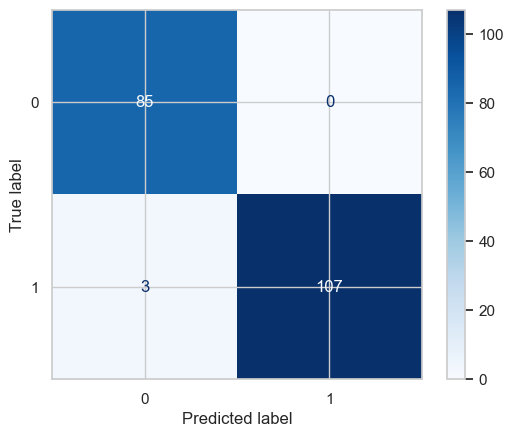

In [37]:
cm = confusion_matrix(y_test, y_predSvm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Svm.classes_)
disp.plot(cmap="Blues")
plt.show()

In [38]:
rkf = RepeatedKFold(n_splits= 5, n_repeats=10, random_state=9)

Svm_cross = cross_val_score(estimator = Svm, X = X_train, y = y_train, cv = rkf)
print(f'Cross-validation scores(SVM): {Svm_cross}')
Svm_cv_score = Svm_cross.mean()
print('Average Cross Validation Recall score: ', Svm_cv_score)

Cross-validation scores(SVM): [1.         0.96794872 1.         0.98076923 0.94871795 0.98076923
 0.96794872 0.96153846 0.98076923 0.98717949 0.96794872 0.96794872
 0.96153846 0.99358974 0.96794872 0.99358974 1.         0.98076923
 0.97435897 1.         0.97435897 0.97435897 0.98717949 0.92948718
 0.98076923 0.97435897 0.99358974 0.96794872 0.96794872 0.98717949
 1.         0.96153846 0.96794872 0.97435897 0.98076923 0.99358974
 0.98717949 1.         0.97435897 0.98717949 0.99358974 0.96153846
 1.         0.96794872 0.97435897 0.96794872 0.98717949 0.99358974
 0.99358974 0.96153846]
Average Cross Validation Recall score:  0.9789743589743591


## SVM shows strong performance with a recall score close to 1, similar to RFC. The range of scores shows slight variability, but the model still performs well across folds.
## The average recall score of 0.9790 is also very competitive, indicating that SVM is highly effective at identifying the positive class, though slightly less so than RFC

### --------------------------------------------------------------------------------------------------------------------------------------------------------------

## the Naive Bayes Model

In [39]:
nbCLF = GaussianNB()

nbCLF.fit(X_train, y_train)

y_predNB = nbCLF.predict(X_test)

print("Classification Report (naive bayes):")
print(classification_report(y_test, y_predNB))

print(f'Accuracy: {accuracy_score(y_test, y_predNB):.2f}')


Classification Report (naive bayes):
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        85
           1       0.83      0.85      0.84       110

    accuracy                           0.82       195
   macro avg       0.82      0.82      0.82       195
weighted avg       0.82      0.82      0.82       195

Accuracy: 0.82


In [40]:
rkf = RepeatedKFold(n_splits= 5, n_repeats=10, random_state=9)

NB_cross = cross_val_score(estimator = nbCLF, X = X_train, y = y_train, cv = rkf)
print(f'Cross-validation scores: {NB_cross}')
rf_cv_score = NB_cross.mean()
print('Average Cross Validation Recall score: ', rf_cv_score)

Cross-validation scores: [0.80769231 0.82051282 0.78846154 0.83974359 0.83974359 0.86538462
 0.83974359 0.79487179 0.80769231 0.80128205 0.82051282 0.77564103
 0.83974359 0.82692308 0.8525641  0.8525641  0.79487179 0.83974359
 0.81410256 0.84615385 0.82051282 0.82692308 0.81410256 0.78205128
 0.81410256 0.84615385 0.78846154 0.79487179 0.80769231 0.85897436
 0.87820513 0.78205128 0.85897436 0.80769231 0.78846154 0.82692308
 0.82692308 0.82051282 0.79487179 0.84615385 0.84615385 0.79487179
 0.84615385 0.79487179 0.78846154 0.78205128 0.80769231 0.83333333
 0.84615385 0.82051282]
Average Cross Validation Recall score:  0.82025641025641


## The Naive Bayes model's recall score is lower than both the Random Forest and SVM models, which suggests that it is not identifying as many positive cases as those models.
## The recall scores are relatively stable, though lower, indicating that the Naive Bayes model is performing consistently but with room for improvement in terms of detecting more positives.
## Average recall of 82% is a reasonable performance, but it may not be enough for tasks where minimizing false negatives is crucial

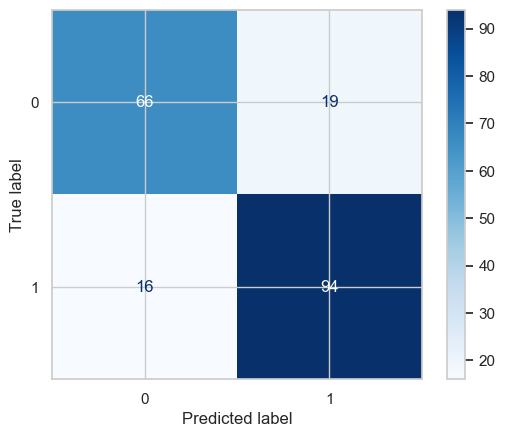

In [41]:
cm = confusion_matrix(y_test, y_predNB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nbCLF.classes_)
disp.plot(cmap="Blues")
plt.show()

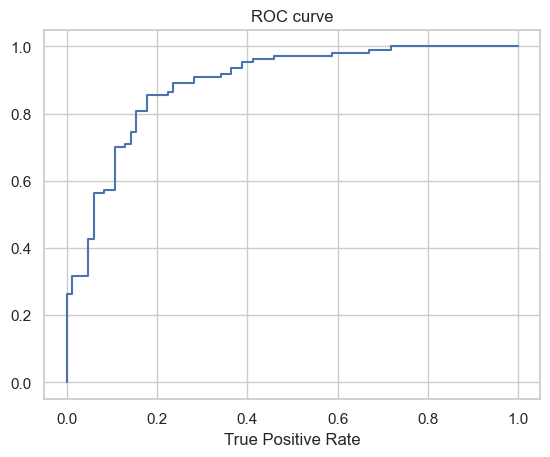

ROC score: 0.89


In [42]:
y_probNB = nbCLF.predict_proba(X_test)[:,1]

falsePosRate, truePosRate, threshold = roc_curve(y_test, y_probNB)

plt.plot(falsePosRate, truePosRate)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("ROC curve")
plt.show()

score = roc_auc_score(y_test, y_probNB)
print(f'ROC score: {score:.2f}')

In [43]:
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=100),          
}
NB = GaussianNB()

gridSearch = GridSearchCV(NB, param_grid, cv = 3,scoring = 'accuracy')

gridSearch.fit(X_train,y_train)

bestNB = gridSearch.best_estimator_
print(bestNB)

GaussianNB(var_smoothing=0.8111308307896871)


In [44]:
nb_CLF = GaussianNB(var_smoothing=0.8111308307896871)

nb_CLF.fit(X_train, y_train)

y_predNb = nb_CLF.predict(X_test)

print("Classification Report (naive bayes):")
print(classification_report(y_test, y_predNb))

print(f'Accuracy: {accuracy_score(y_test, y_predNb):.2f}')

Classification Report (naive bayes):
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        85
           1       0.83      0.89      0.86       110

    accuracy                           0.84       195
   macro avg       0.84      0.83      0.83       195
weighted avg       0.84      0.84      0.83       195

Accuracy: 0.84


In [45]:
rkf = RepeatedKFold(n_splits= 5, n_repeats=10, random_state=9)

Nb_cross = cross_val_score(estimator = nb_CLF, X = X_train, y = y_train, cv = rkf)
print(f'Cross-validation scores(NB): {NB_cross}')
NB_cv_score = Nb_cross.mean()
print('Average Cross Validation Recall score: ', NB_cv_score)

Cross-validation scores(NB): [0.80769231 0.82051282 0.78846154 0.83974359 0.83974359 0.86538462
 0.83974359 0.79487179 0.80769231 0.80128205 0.82051282 0.77564103
 0.83974359 0.82692308 0.8525641  0.8525641  0.79487179 0.83974359
 0.81410256 0.84615385 0.82051282 0.82692308 0.81410256 0.78205128
 0.81410256 0.84615385 0.78846154 0.79487179 0.80769231 0.85897436
 0.87820513 0.78205128 0.85897436 0.80769231 0.78846154 0.82692308
 0.82692308 0.82051282 0.79487179 0.84615385 0.84615385 0.79487179
 0.84615385 0.79487179 0.78846154 0.78205128 0.80769231 0.83333333
 0.84615385 0.82051282]
Average Cross Validation Recall score:  0.8333333333333333


## the NB model shows more variability in recall scores, with a noticeable drop from the first two models. Although it still performs reasonably well, it has a lower recall score, meaning it is not as effective at identifying positive instances.
## The average recall score of 0.8333 is significantly lower than both RFC and SVM, which indicates this model might be less reliable in its predictions, potentially leading to more false negatives.

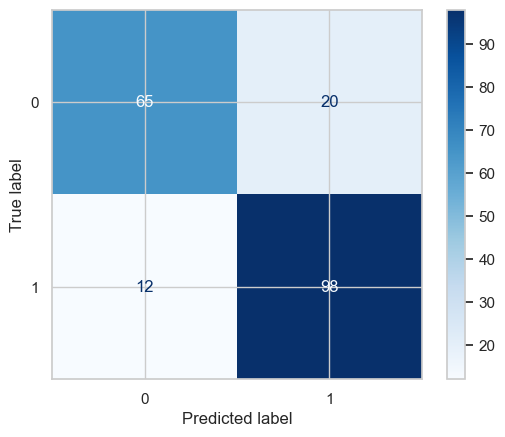

In [46]:
cm = confusion_matrix(y_test, y_predNb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_CLF.classes_)
disp.plot(cmap="Blues")
plt.show()

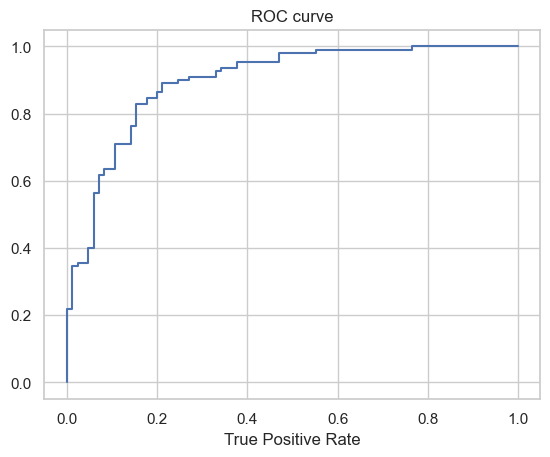

ROC score: 0.90


In [47]:
y_probNb = nb_CLF.predict_proba(X_test)[:,1]

falsePosRate, truePosRate, threshold = roc_curve(y_test, y_probNb)

plt.plot(falsePosRate, truePosRate)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("ROC curve")
plt.show()

score = roc_auc_score(y_test, y_probNb)
print(f'ROC score: {score:.2f}')

### preformance: An AUC of 0.90 indicates that the model has high discriminative ability, meaning it does a great job of distinguishing between the positive and negative classes.

### Interpretation: If you randomly select one positive instance and one negative instance, there is a 90% chance that the model will correctly rank the positive instance higher than the negative one. In other words, the model is 90% likely to correctly identify the positive class when compared to a random selection.

### --------------------------------------------------------------------------------------------------------------------------------------------------------------

# Comparison:
### Best performer: Random Forest Classifier (RFC) achieves the highest average recall score (0.9818), indicating the best performance overall in identifying positive cases.
### Second-best performer: Support Vector Machine (SVM) follows closely with a recall score of 0.9790, making it a strong contender but slightly less effective than RFC.
### Third-best performer: The NB model shows the lowest average recall score (0.8333), indicating that its ability to detect positive cases is considerably lower than the other two models.

# Conclusion:
### RFC seems to be the best model, achieving the highest recall score, which is crucial in situations where identifying all positive cases is essential.
### SVM is also a strong model, performing slightly worse than RFC but still offering good performance.
### The NB model, while still decent, lags behind both RFC and SVM in recall, making it less optimal for tasks requiring high recall.